# **Main Notebook: AI School 2: Deep Learning Foundations and Neural Network with PyTorch**

## Intro to Deep Learning Foundations

In this section, we will cover the foundational concepts of deep learning: gradient descent, backpropagation, and neural networks.

### General Idea behind Machine Learning

In order for our algorithms to function well, they make use training data to learn trends and find patterns. This training data has two parts, the input which is that actually data, and the label, which is what the data actually is. By using the input data to train and produce an output, we can see how our machine learning model is performing by comparing those outputs with the actual labels as seen below.

![image1](https://external-content.duckduckgo.com/iu/?u=http%3A%2F%2Fdrive.google.com/uc?id=12my-8ITo9zK1Ab-7hEiTfsfJV7rO2WyO)

In general, the goal with machine learning is to make the most optimal "y" my changing the parameters "Θ" in the equation: <i> x*Θ = y </i> (this is a linear model example).

![image2](https://external-content.duckduckgo.com/iu/?u=http%3A%2F%2Fdrive.google.com/uc?id=12j_d6T1hYb6HySvRZWi2vCX90Y0LCjZ-)

In other words we are trying to build the best line that describes our data plot. We can continue to improve the and modify the parameters through the use of a loss function.

### Loss Functions
In simple terms, a loss function is a way to compare our true labels to the output of the model. As mentioned before, we need to understand the performance of our model to know how to improve it. Since we are working with classification and images, lets take a look at two popular loss functions for what we are dealing with.

#### Binary Cross-Entropy/Log Loss

![image4](https://external-content.duckduckgo.com/iu/?u=http%3A%2F%2Fdrive.google.com/uc?id=1VsyiCrnMn7-kCTZynpjZplqBNe2iBPhA)

This first function is a binary function that calculates the loss when we only have two classifications.

#### Categorical Cross-Entropy Loss
![image3](https://external-content.duckduckgo.com/iu/?u=http%3A%2F%2Fdrive.google.com/uc?id=16nFiF_IriJifTZvebgreCdQ1c0fDzBOu)

This second function also calculates the loss just as the first function, but this time for situations where there are more that two classifications.

In these equations, i represents the current x (data) you are looking at, y is the true label, p is the prediction that is given from the model, and the summation multiplied by 1/n is to account for and average all of the errors between each x and y pairing.

### Gradient Descent

Gradient Descent is one way to optmize our model since we don't know what the best parameters are (loss functions only tell us the performance of the model).

# Intro to PyTorch


### Tensors
Before we talk about the flashy ✨ AI ML model ✨, we need to understand the abstract data type used in all Machine Learning models.

WHAT ARE TENSORS?
Multi-dimensional arrays, generalized from matrices
Tensors can hold different types of information that can be useful in a neural network

Thankfully, we have the Pytorch documentation to save us from having to dive too much into Math, at least for `torch.Tensor`

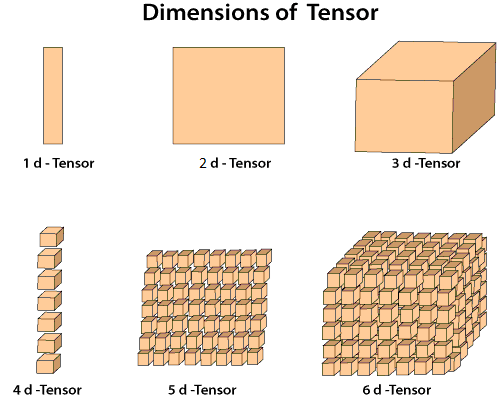

### Initialize empty tensors

In [ ]:
import torch
x = torch.empty(1, 2)
x.shape

### Create a Tensor full of zeros

In [ ]:
torch.zeros(1, 2)

### Basic Arithmetic with `torch.Tensor`

In [ ]:
#addition
a = torch.ones(1, 2)
#multiplication
b = torch.ones(1, 2) * 2

print(a)
print(b)
print(a + b)

try and predict what the code below will return!

In [ ]:
tensor_1 = torch.tensor([[1,2], [3,4]])
tensor_2 = torch.tensor([[4,5], [6,7]])
#element wise multiplication
c = tensor_1 * tensor_2
print(c)

### Reshaping tensors

In [ ]:
reshaped = tensor_1.view(4)
print(reshaped)
#reshape it back!
reshaped = reshaped.view(2,2)
print(reshaped)

### Flattening tensors

In [ ]:
print(tensor_1)
print(tensor_1.flatten())

###Why are tensors important?
Tensors are the foundational data structure for deep learning frameworks

They allow for efficient storage and manipulation of multi-dimensional data (e.g., images, videos).

Enable seamless transitions between CPU and GPU, making it easier to leverage hardware acceleration.


#How are tensors used?
Tensors hold input data like images, text, or any structured data fed into the network
- Weights and biases in each layer of a neural network are stored as tensors
- During training, tensors store gradients, which represent the partial derivatives of the loss with respect to each weight and bias in the network.


For the people who want to learn more:

- [`torch.linalg`](https://pytorch.org/docs/stable/linalg.html)
- [Math operations within `torch`](https://pytorch.org/docs/stable/torch.html#math-operations)

# Workshop Project: Image Classification with USPS Dataset

For this project, we will be looking at a dataset of handwritten digits scanned from USPS envelopes. We will use image classification to identify the digit pictured.

Task: Create a neural network module with PyTorch that trains on Google Colab's GPU and learns to classify handwritten digits using [USPS dataset](https://pytorch.org/vision/master/generated/torchvision.datasets.USPS.html).

Here's a step-by-step overview:

1. Import modules
2. Specify the computing device you will be using (CPU or GPU)
3. Build your neural network architecture with `nn.Module`
4. Train on the [USPS dataset](https://pytorch.org/vision/master/generated/torchvision.datasets.USPS.html).
5. Test it with the test set.

### Import modules

In [ ]:
import matplotlib.pyplot as plt
import os
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

### Specify computing device
You can switch the computing device in Colab by selecting Runtime > Change runtime type. For this project, let's select T4 GPU.

Note that changing the device resets your variables, so you will need to run the import cell again.

In [ ]:
device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using {device} device")

Quick check: If you are on GPU, the cell above should output `Using cuda device`!

### Load datasets

In [ ]:
from torchvision import datasets, transforms

# Check if cuda is available in PyTorch
use_cuda = torch.cuda.is_available()

**Batch size**

The batch size represents how many samples we will use in each learning iteration of our model.

The smallest possible batch size is 1, in which case the model updates its parameters after looking at every sample. This method is equivalent to stochastic gradient descent and could have somewhat noisy training loss, as the model spreads itself thin trying to optimize for every individual sample.

The largest possible batch size is the size of the dataset, in which case the model updates its parameters only after checking its performance on the whole dataset. A batch size that is too large can lead to the model overfitting to the training data, as it isn't being trained to recognize any data it hasn't seen before.

<img width="500" src="https://media.geeksforgeeks.org/wp-content/uploads/20241227180043503430/Understanding-Batch-Size-in-Neural-Network.webp" alt="batch size comparison">

The ideal batch size varies depending on the data and the type of model. In the diagram above, you can see that the mini batch has the middle amount of noise and trains the fastest. For this project, let's try a batch size of 50.

In [ ]:
BATCH_SIZE = 50
TEST_BATCH_SIZE = 50

Now, let's set up the cuda.

In [ ]:
# train_kwargs: Keyword Arguments for Training
# test_kwargs: Keyword Arguments for Testing
train_kwargs = {"batch_size": BATCH_SIZE}
test_kwargs = {"batch_size": TEST_BATCH_SIZE}

if use_cuda:
    cuda_kwargs = {'num_workers': 1,
                   'pin_memory': True,
                   'shuffle': True}
    device = torch.device("cuda")
    train_kwargs.update(cuda_kwargs)
    test_kwargs.update(cuda_kwargs)
else:
    devce = torch.device("cpu")

### Data transformations
In the previous wiki page, we learned about data transformations. Feel free to refer back to it.

Your task: Using transforms.Compose, add transformations to our image data:

*   Convert to tensor
*   Normalize with the parameter `(0.1307,), (0.3081,)`



In [ ]:
# Your turn!

transform=transforms.Compose([
    # write your transformations here
])

assert len(transform.transforms) > 0, "Remember to add your transforms!"

In [ ]:
#@title Solution

transform=transforms.Compose([
  transforms.ToTensor(),
  transforms.Normalize((0.1307,), (0.3081,))
])

Now, let's get the training and testing datasets and loaders.

You will probably find this documentation helpful:

* [USPS datasets](https://docs.pytorch.org/vision/main/generated/torchvision.datasets.USPS.html)
* [DataLoaders](https://docs.pytorch.org/tutorials/beginner/basics/data_tutorial.html#preparing-your-data-for-training-with-dataloaders)

In [ ]:
# Your turn!

train_dataset = None
test_dataset = None

train_loader = None
test_loader = None

assert train_dataset is not None, "Please fill in each line."
assert test_dataset is not None, "Please fill in each line."
assert train_loader is not None, "Please fill in each line."
assert test_loader is not None, "Please fill in each line."

In [ ]:
#@title Solution
train_dataset = datasets.USPS('./data/usps/train', train=True, transform=transform, download=True)
test_dataset = datasets.USPS('./data/usps/test', train=False, transform=transform, download=True)

train_loader = DataLoader(train_dataset, BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, TEST_BATCH_SIZE, shuffle=True)

Using the image loader, let's get the next training data sample so we can visualize it.

Hint: Convert `train_loader` to an [iterator](https://docs.python.org/3/library/functions.html#iter) object, then use the [next function](https://docs.python.org/3/library/functions.html#next) to get the next element.

In [ ]:
# Your turn!

train_features, train_labels = # add your code here
print(f"Feature batch shape: {train_features.size()}")
print(f"Labels batch shape: {train_labels.size()}")
img = train_features[0].squeeze()
label = train_labels[0]
plt.imshow(img, cmap="gray")
plt.show()
print(f"Label: {label}")

In [ ]:
#@title Solution
train_features, train_labels = next(iter(train_loader))
print(f"Feature batch shape: {train_features.size()}")
print(f"Labels batch shape: {train_labels.size()}")
img = train_features[0].squeeze()
label = train_labels[0]
plt.imshow(img, cmap="gray")
plt.show()
print(f"Label: {label}")

Feel free to keep running the above cell to see more images!

### Progress check:

You can type in the blanks for your own reference, but it won't check your answers. The solutions are in the cell underneath.

1.   What are the dimensions of each image, in pixels? <input type="text"/>
2.   How many output classes are there, and what are they? <input type="text"/>
3.   What are the dimensions of each image after its data, as a tensor, has been flattened? <input type="text"/>



### Solution


1. Each image is 16x16 pixels. Notice that the feature batch shape is [50, 1, 16, 16]—50 images per batch, 1 color channel (for black & white), and the dimensions are 16x16.
2. There are 10 output classes, which are the 10 digits (0 to 9).
3. Each image has shape [1, 16, 16]. The tensor has 1•16•16=256 entries. When it's flattened, the shape will simply be an array of length 256.

### Train your model

Let's set up a neural network! We will have the following layers:

* `nn.Linear(16*16, 512)` - The first layer has 256 inputs since that's the size of a flattened image. It has 512 outputs.

* `nn.ReLU()` - The next layer is a ReLU layer. You can read more about it [here](https://docs.pytorch.org/docs/stable/generated/torch.nn.ReLU.html). ReLU is a commonly used type of activation function. It is necessary because without any activation function, the entire model would be linear layers, which would highly restrict what the model could learn.

* `nn.Linear(512, 512)` - The middle linear layer which gives our models more parameters that can be trained.

* `nn.ReLU()` - Another ReLU layer to break up the linear layers.

* `nn.Linear(512, 10)` - The last layer connects the 512 neurons of the last layer to the 10 output classes that we need for recognizing digits.


Helpful documentation:
* [nn.Sequential](https://docs.pytorch.org/docs/stable/generated/torch.nn.Sequential.html)

In [ ]:
# TODO: Define your Neural Network module
class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        # Initialize the flatten function using nn.Flatten.
        self.flatten = nn.Flatten()

        # Initialize the stack of layers. Use nn.Sequential and check out the
        # outline of layers in the text cell above.
        self.linear_relu_stack = None # TODO


    def forward(self, x):
        x = None # TODO: flatten the input image x
        logits = None # TODO: pass x through the layer stack
        return logits

model: NeuralNetwork = None # TODO

assert model is not None, "No model found"

In [ ]:
#@title Solution

class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        # Initialize the flatten function using nn.Flatten.
        self.flatten = nn.Flatten()

        # Initialize the stack of layers. Use nn.Sequential for that.
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(16*16, 512),
            nn.ReLU(),
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Linear(512, 10),
        )

    def forward(self, x):
        x = self.flatten(x)
        logits = self.linear_relu_stack(x)
        return logits

model: NeuralNetwork = NeuralNetwork()

Define the training loop

In [ ]:
def train_loop(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset)
    # Set the model to training mode - important for batch normalization and dropout layers
    # Unnecessary in this situation but added for best practices
    model.train()
    for batch, (X, y) in enumerate(dataloader):
        # Compute prediction and loss
        pred = model(X)
        loss = loss_fn(pred, y)

        # Backpropagation
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        if batch % 100 == 0:
            loss, current = loss.item(), batch * batch_size + len(X)
            print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")


def test_loop(dataloader, model, loss_fn):
    # Set the model to evaluation mode.
    # This is important for batch normalization and dropout layers.
    # Unnecessary in this situation but added for best practices.
    # See https://pytorch.org/docs/stable/_modules/torch/nn/modules/module.html#Module.eval to learn more about model evaluation mode.
    # And my turn to ask you know, when is model evaluation mode needed?
    #
    # Answer:
    # Batch Normalization: During training, it uses batch statistics to
    # normalize the activations.
    # During evaluation, it uses running statistics computed during training.
    #
    # Dropout: During training, it randomly drops out neurons to prevent
    # overfitting.
    # During evaluation, it uses all neurons to get the most accurate
    # prediction.

    model.eval()
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    test_loss, correct = 0, 0

    # Evaluating the model with torch.no_grad() ensures that no gradients are computed during test mode
    # also serves to reduce unnecessary gradient computations and memory usage for tensors with requires_grad=True
    with torch.no_grad():
        for X, y in dataloader:
            pred = model(X)
            test_loss += loss_fn(pred, y).item()
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()

    test_loss /= num_batches
    correct /= size
    print(f"Test Error: \n Accuracy: {(100*correct):>0.1f}%, Avg loss: {test_loss:>8f} \n")


Fill in the blanks!

What loss function should we use? Hint: We have 10 output classes.

Let's use torch.optim.SGD as our optimizer.

Helpful documentation:
* [Binary Cross Entropy](https://docs.pytorch.org/docs/stable/generated/torch.nn.BCELoss.html)
* [Categorical Cross Entropy](https://docs.pytorch.org/docs/stable/generated/torch.nn.CrossEntropyLoss.html)
* [torch.optim.SGD](https://docs.pytorch.org/docs/stable/generated/torch.optim.SGD.html)

In [ ]:
learning_rate = 1e-3

# Initialize the loss function
loss_fn = None
optimizer = None

assert loss_fn is not None, "No loss_fn found"
assert optimizer is not None, "No optimizer found"

In [ ]:
#@title Solution
learning_rate = 1e-3

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

In [ ]:
epochs = 10 # add more epochs for better results

for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    train_loop(train_loader, model, loss_fn, optimizer)
    test_loop(test_loader, model, loss_fn)
print("Done!")

### Congrats on creating a neural network!! 🎉

## (Extension) Make the model perform better 🧠

OK so how can we make the model perform better? And what did I mean by "better"?

For the purpose of this lesson, let's make the final accuracy on test set the metric for a better model. The higher the accuracy, the better it is.

There are many ways to make your neural network model better.

Here are a few pointers:

- Read this blog post from the goat Andrej Karpathy on [recipes for training neural networks](http://karpathy.github.io/2019/04/25/recipe/).

- Experiment with different optimizers. Take a look at [`torch.optim`](https://pytorch.org/docs/stable/optim.html)

- Try using Learning Rate Scheduling like `torch.optim.lr_scheduler.StepLR`. For how you can adjust learning rate, see [here](https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate).

- Increase the number of epochs
- Add regularization. Try using drop out layers.
- More data augmentation. (Pop quiz, how do you do that? by editing what?)